In [283]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv("../datasets/aac_intakes_outcomes.csv")


In [284]:
df.head(5)
df.shape

(79672, 41)

In [285]:
df["outcome_type"].unique()

<StringArray>
['Return to Owner',        'Transfer',        'Adoption',      'Euthanasia',
            'Died',       'Rto-Adopt',         'Missing',        'Disposal',
               nan,        'Relocate']
Length: 10, dtype: str

In [286]:
#Remove columns
df = df.drop(columns=["age_upon_outcome_(years)", "age_upon_outcome_age_group", "outcome_month", "outcome_year", "outcome_monthyear", "outcome_weekday", "outcome_hour", "outcome_number", "dob_monthyear", "count", "age_upon_intake_(years)", "age_upon_intake_age_group", "intake_month", "intake_year", "intake_monthyear", "intake_weekday", "intake_hour", "time_in_shelter_days", "dob_year", "dob_month", "age_upon_intake"])

In [287]:
#Check for duplicate rows
df = df.drop_duplicates()
df.shape


(79637, 20)

In [288]:
# Change foster adoptions to foster and drop outcome_subtype
foster_adoptions = (df["outcome_type"] == "Adoption") & (df["outcome_subtype"] == "Foster")
df.loc[foster_adoptions, "outcome_type"] = "Foster"
df = df.drop(columns=["outcome_subtype"])
#df.isna().sum()


In [289]:
#convert age_upon_outcome_(days) and age_upon_intake_(days) to age_upon_outcome_(years) and age_upon_intake_(years)
df["age_upon_outcome_(years)"] = df["age_upon_outcome_(days)"] / 365
df["age_upon_intake_(years)"] = df["age_upon_intake_(days)"] / 365
df = df.drop(columns=["age_upon_outcome_(days)", "age_upon_intake_(days)"])

df.head(5)

,age_upon_outcome,animal_id_outcome,date_of_birth,outcome_type,sex_upon_outcome,outcome_datetime,animal_id_intake,animal_type,breed,color,found_location,intake_condition,intake_type,sex_upon_intake,intake_datetime,intake_number,time_in_shelter,age_upon_outcome_(years),age_upon_intake_(years)
0,10 years,A006100,2007-07-09 00:00:00,Return to Owner,Neutered Male,2017-12-07 14:07:00,A006100,Dog,Spinone Italiano Mix,Yellow/White,Colony Creek And Hunters Trace in Austin (TX),Normal,Stray,Neutered Male,2017-12-07 00:00:00,1.0,0 days 14:07:00.000000000,10.0,10.0
1,7 years,A006100,2007-07-09 00:00:00,Return to Owner,Neutered Male,2014-12-20 16:35:00,A006100,Dog,Spinone Italiano Mix,Yellow/White,8700 Research Blvd in Austin (TX),Normal,Public Assist,Neutered Male,2014-12-19 10:21:00,2.0,1 days 06:14:00.000000000,7.0,7.0
2,6 years,A006100,2007-07-09 00:00:00,Return to Owner,Neutered Male,2014-03-08 17:10:00,A006100,Dog,Spinone Italiano Mix,Yellow/White,8700 Research in Austin (TX),Normal,Public Assist,Neutered Male,2014-03-07 14:26:00,3.0,1 days 02:44:00.000000000,6.0,6.0
3,10 years,A047759,2004-04-02 00:00:00,Transfer,Neutered Male,2014-04-07 15:12:00,A047759,Dog,Dachshund,Tricolor,Austin (TX),Normal,Owner Surrender,Neutered Male,2014-04-02 15:55:00,1.0,4 days 23:17:00.000000000,10.0,10.0
4,16 years,A134067,1997-10-16 00:00:00,Return to Owner,Neutered Male,2013-11-16 11:54:00,A134067,Dog,Shetland Sheepdog,Brown/White,12034 Research Blvd in Austin (TX),Injured,Public Assist,Neutered Male,2013-11-16 09:02:00,1.0,0 days 02:52:00.000000000,16.0,16.0


In [293]:
# Convert time_in_shelter to numeric values
df["time_in_shelter"] = pd.to_timedelta(df["time_in_shelter"])
df["time_in_shelter_days"] = df["time_in_shelter"].dt.total_seconds() / (60 * 60 * 24)

df.head(5)

,age_upon_outcome,animal_id_outcome,date_of_birth,outcome_type,sex_upon_outcome,outcome_datetime,animal_id_intake,animal_type,breed,color,found_location,intake_condition,intake_type,sex_upon_intake,intake_datetime,intake_number,time_in_shelter,age_upon_outcome_(years),age_upon_intake_(years),time_in_shelter_days
0,10 years,A006100,2007-07-09 00:00:00,Return to Owner,Neutered Male,2017-12-07 14:07:00,A006100,Dog,Spinone Italiano Mix,Yellow/White,Colony Creek And Hunters Trace in Austin (TX),Normal,Stray,Neutered Male,2017-12-07 00:00:00,1.0,0 days 14:07:00,10.0,10.0,0.588194
1,7 years,A006100,2007-07-09 00:00:00,Return to Owner,Neutered Male,2014-12-20 16:35:00,A006100,Dog,Spinone Italiano Mix,Yellow/White,8700 Research Blvd in Austin (TX),Normal,Public Assist,Neutered Male,2014-12-19 10:21:00,2.0,1 days 06:14:00,7.0,7.0,1.259722
2,6 years,A006100,2007-07-09 00:00:00,Return to Owner,Neutered Male,2014-03-08 17:10:00,A006100,Dog,Spinone Italiano Mix,Yellow/White,8700 Research in Austin (TX),Normal,Public Assist,Neutered Male,2014-03-07 14:26:00,3.0,1 days 02:44:00,6.0,6.0,1.113889
3,10 years,A047759,2004-04-02 00:00:00,Transfer,Neutered Male,2014-04-07 15:12:00,A047759,Dog,Dachshund,Tricolor,Austin (TX),Normal,Owner Surrender,Neutered Male,2014-04-02 15:55:00,1.0,4 days 23:17:00,10.0,10.0,4.970139
4,16 years,A134067,1997-10-16 00:00:00,Return to Owner,Neutered Male,2013-11-16 11:54:00,A134067,Dog,Shetland Sheepdog,Brown/White,12034 Research Blvd in Austin (TX),Injured,Public Assist,Neutered Male,2013-11-16 09:02:00,1.0,0 days 02:52:00,16.0,16.0,0.119444


<Figure size 600x400 with 0 Axes>

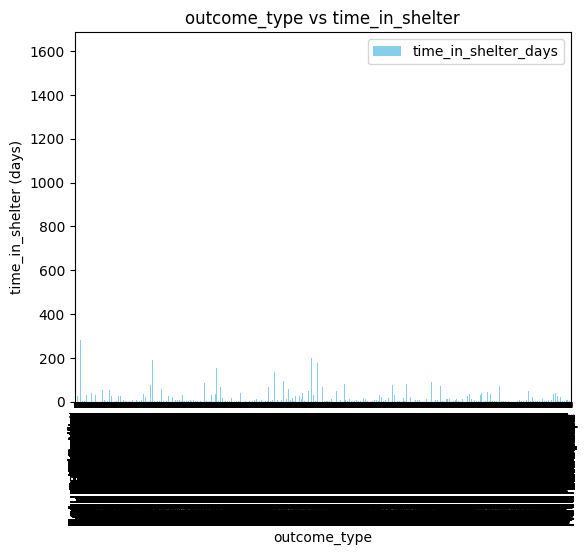

In [294]:
#Compare outcome_type and time_in_shelter 
plt.figure(figsize=(6, 4))
df.plot(x='outcome_type', y='time_in_shelter_days', kind='bar', color='skyblue')
plt.title('outcome_type vs time_in_shelter')
plt.xlabel('outcome_type')
plt.ylabel('time_in_shelter (days)')
plt.show()




In [ ]:
#Compare age and time_in_shelter


In [ ]:
#Compare dog vs cat and time_in_shelter


In [ ]:
#Compare intake_condition and time_in_shelter

In [ ]:
#Compare breed and time_in_shelter

In [ ]:
#Compare neutered vs not neutered and time_in_shelter

In [ ]:
#Count intakes by month

In [ ]:
#Count outcomes by month